In [1]:
import os
import json
import yaml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import sem
from scipy.stats import ranksums

def read_config(file_path):
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

def is_config_valid(config, ref_config, ignore_fields):
    for key, value in ref_config.items():
        if key not in ignore_fields and config.get(key) != value:
            print(key, config.get(key))
            return False
    return True

def valid_directories(search_path, ref_config, config_ignore_fields):
    valid_dirs = []
    for directory in os.listdir(search_path):
        dir_path = os.path.join(search_path, directory)
        config_path = os.path.join(dir_path, 'config.yaml')
        if os.path.isfile(config_path):
            config = read_config(config_path)
            if (ref_config is None) or is_config_valid(config, ref_config, config_ignore_fields):
                valid_dirs.append(directory)
    return valid_dirs

def read_epochs_data(file_path):
    with open(file_path, 'r') as file:
        return [json.loads(line) for line in file]

def is_run_valid(epoch_data, min_epoch,require_finish_flag=True, finish_flag=None):
    if require_finish_flag:
        return len(epoch_data) >= min_epoch and os.path.isfile(finish_flag)
    else:
        return len(epoch_data) >= min_epoch

def aggregate_results(valid_dirs, min_epoch, search_path, use_test):
    all_results = {}
    all_configs ={}
    for dir_name in valid_dirs:
        dir_path = os.path.join(search_path, dir_name)
        if use_test:
            results_path = os.path.join(dir_path, 'results', 'test_data.json')
            min_epoch = 0
        else:
            results_path = os.path.join(dir_path, 'results', 'epoch_data.json')
        config_path = os.path.join(dir_path, 'config.yaml')
        if os.path.isfile(results_path):
            epoch_data = read_epochs_data(results_path)
            if is_run_valid(epoch_data, 
                            min_epoch, 
                            require_finish_flag=True, 
                            finish_flag = os.path.join(dir_path,'run_finished')):
#             if  os.path.isfile(os.path.join(dir_path,'run_finished')):
                dir_results = {}
                for epoch in epoch_data:
                    for key, value in epoch.items():
                        if key not in dir_results:
                            dir_results[key] = []
                        dir_results[key].append(value)
                all_results[dir_name] = dir_results
                all_configs[dir_name] = read_config(config_path)
    return all_results, all_configs

# Main function
def analyze_runs(ref_config_path, search_path, config_ignore_fields, min_epoch, use_test):
    ref_config = read_config(ref_config_path) if ref_config_path is not None else None
    valid_dirs = valid_directories(search_path, ref_config, config_ignore_fields)
#     print(valid_dirs)
    return aggregate_results(valid_dirs, min_epoch, search_path, use_test)

def mean_k_last_result(result_dicts,key,k_last, as_dict=False):
    results = {} if as_dict else []
    for run_name, result_dict in result_dicts.items():
        if key in result_dict.keys():
            this_result = np.mean(result_dict[key][-k_last:])
            if as_dict:
                results[run_name] = this_result
            else:
                results.append(this_result)
        else:
            print(f'warning, no such a field in run name:{run_name}')
    return results


def mean_std_of_not_too_low(x,rtol=0.1):
#     print(x)
    ref = np.max(x)
    ii = x>ref*(1-rtol)
#     if not np.alltrue(ii):
    if not np.all(ii):
        print('WARNING, some runs discarded:', ii)
    return np.mean(x[ii]), np.std(x[ii]), np.sum(ii), sem(x[ii])

def fb_p_value(x, ds, dist):
#     print(x)
#     print(ds)
#     print(dist)
    pvalue = 1.0
    fb_acc_vals = []
    
    # FMNIST D1
    if ds=='FMNIST' and dist=='D1':
        fb_acc_vals = [0.8245, 0.826,  0.8241, 0.8256, 0.8202]#fb fmnist D1- 20250728
    elif ds=='KMNIST' and dist=='D1':
        fb_acc_vals = [0.8668, 0.8703, 0.8705, 0.8714, 0.8707]#fb kmnist D1- 20250729
    elif ds=='MNIST' and dist=='D1':
        fb_acc_vals = [0.9078, 0.9057, 0.9077, 0.9061, 0.9085]#fb mnist D1- 20250722
    elif ds=='MNIST' and dist=='D2':
        fb_acc_vals = [0.7027, 0.7048, 0.7026, 0.6974, 0.705 ]#fb mnist D2
    elif ds=='FMNIST' and dist=='D2':
        fb_acc_vals = [0.7398, 0.7383, 0.7371, 0.7393, 0.7399]#fb fmnist D2
    elif ds=='KMNIST' and dist=='D2':
        fb_acc_vals =  [0.7071, 0.7071, 0.703,  0.7072, 0.7039]#fb kmnist D2

    if fb_acc_vals:
        statistic, pvalue = ranksums(x, fb_acc_vals, alternative='two-sided')#, alternative='greater')

    return pvalue, (np.mean(x)>np.mean(fb_acc_vals))


In [2]:
#rev3: changed datasets after revision and re-acquiring of all datasets

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def add_inset_with_symbols(ax, width="30%", height="30%", loc=1, 
                           styles=None, titles = None, 
                           bbox=(0.5, 0.5, 0.5, 0.5)):
    """
    Add an inset to the given axis with symbols and their meanings.

    Parameters:
    ax (matplotlib.axes.Axes): The axis to add the inset to.
    width (str): Width of the inset as a percentage of the parent axis.
    height (str): Height of the inset as a percentage of the parent axis.
    loc (int): Location code for the inset (1=upper right, 2=upper left, etc.).
    """
    # Define inset axis
    inset_ax = inset_axes(ax, width=width, height=height, bbox_to_anchor=bbox, loc=loc,
                         bbox_transform=ax.transAxes)

    # Add the symbols and their meanings to the inset

    for style, title in zip(styles, titles):
        inset_ax.plot([], [], style, label=title)

    # Hide the inset axis ticks and labels
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.legend(loc='center')

In [4]:
# ds_LUT = {'20240623':{'ds':'MNIST', 'dist':'D1'},
#           '20240707':{'ds':'MNIST', 'dist':'D2'},
#           '20240801':{'ds':'FMNIST', 'dist':'D1'}, #change in rev2
#           '20240728':{'ds':'FMNIST', 'dist':'D2'}, #change in rev2
#           '20240703':{'ds':'KMNIST', 'dist':'D1'},
#           '20240705':{'ds':'KMNIST', 'dist':'D2'},
#          }

ds_LUT = {'20250724':{'ds':'MNIST', 'dist':'D1'},
          '20250803':{'ds':'FMNIST', 'dist':'D1'},
          '20250730_2':{'ds':'KMNIST', 'dist':'D1'},
          '20250809':{'ds':'MNIST', 'dist':'D2'},
          '20250810_2':{'ds':'FMNIST', 'dist':'D2'},
          '20250909':{'ds':'KMNIST', 'dist':'D2'}
         }

In [5]:
#copied from rev1_fig_acc_over_frameexp_and_baseline,ipynb (D1-config 2, D2-config 3)
frames_LUT ={('MNIST','D1'): 0.907,
             ('MNIST','D2'): 0.703,
             ('FMNIST','D1'): 0.824,
             ('FMNIST','D2'): 0.739,
             ('KMNIST','D1'): 0.870,
             ('KMNIST','D2'): 0.706,
            }

In [3]:
!pwd

/home/labs/ahissarlab/bnassa/event-based-hyperacuity/notebooks


In [5]:
!grep config_file  ../saved_runs/acc_vs_events_num/ebtMNISTD1_20250724_64_supervised_sweep_767193/config.yaml 

config_file: config/config_ebtMNISTD1_20250724_PTr.yaml


In [7]:
!diff ../saved_runs/acc_vs_events_num/ebtMNISTD1_20250724_64_supervised_sweep_767193/config.yaml ../saved_runs/acc_vs_events_num/ebtMNISTD1_20250724_32_supervised_sweep_510100/config.yaml 

7c7
< ds_args_n_samples: 64
---
> ds_args_n_samples: 32
23c23
< job_id: '767193'
---
> job_id: '510100'
25,26c25,26
< json_log: ./saved_runs/ebtMNISTD1_20250724_64_supervised_sweep_767193/results/epoch_data.json
< json_test_data: ./saved_runs/ebtMNISTD1_20250724_64_supervised_sweep_767193/results/test_data.json
---
> json_log: ./saved_runs/ebtMNISTD1_20250724_32_supervised_sweep_510100/results/epoch_data.json
> json_test_data: ./saved_runs/ebtMNISTD1_20250724_32_supervised_sweep_510100/results/test_data.json
50c50
< run_name: ebtMNISTD1_20250724_64_supervised_sweep_767193
---
> run_name: ebtMNISTD1_20250724_32_supervised_sweep_510100
53c53
< seed: 46
---
> seed: 42


In [6]:
min_epoch = 0
use_test = True
search_path = '../saved_runs/acc_vs_events_num/'

ref_config_paths = {'full_table':'../saved_runs/acc_vs_events_num/ebtMNISTD1_20250724_64_supervised_sweep_767193/config.yaml',
                      }

config_ignore_fields_s = {'full_table':['json_log', 'run_name', 'seed', 'ds_args_n_samples','config_file',
                        'json_test_data', 'check_job_recovery','eb_ds_path', 'job_id', 
                        'resume_run_name', 'run_name_history', 'model_args_offsets']}
                        
dfs = {}

for this_mode in ref_config_paths:
    dfs[this_mode] = {}
    ref_config_path =ref_config_paths[this_mode]
    config_ignore_fields =config_ignore_fields_s[this_mode]
    result_dicts, config_dicts = analyze_runs(ref_config_path, search_path, config_ignore_fields, min_epoch, 
                                                  use_test=use_test)
    full_dict = {k:{**config_dicts[k],**result_dicts[k]} for k in result_dicts}
    dfs[this_mode] = pd.DataFrame(full_dict).transpose()
    dfs[this_mode]['test_acc'] = dfs[this_mode]['test_acc'].map(lambda x: x[0])
    print(f'found {len(full_dict)} runs for mode {this_mode}')

found 210 runs for mode full_table


In [7]:
def squeeze_dict(d):
    return d[[k for k in d.keys()][0]]

In [8]:
df = squeeze_dict(dfs)

In [9]:
dataset_names = [job[:11] for job in df.index]
# dataset_names
df[(df['ds_args_n_samples']==48) & (np.array(dataset_names)=='ebtKMNISTD1')]


,batch_size,check_job_recovery,config_file,dataset,disable_data_parallel,do_warmup,ds_args_n_samples,ds_args_one_hot_coordinates,ds_args_shuffle_events,ds_args_train_from_time_interval,...,save_path,seed,supervision_mode,train_head_only,use_sgd,epoch,test_loss,test_acc,test_avg_acc,test_time
ebtKMNISTD1_20250730_2_supervised_sweep_982386,64,True,config/config_ebtKMNISTD1_20250730_2_PTr.yaml,eb_ds,False,True,48,False,False,"[70, 180]",...,./saved_runs/,44,supervised,False,False,[0],[0.5162582817077637],0.8477,[0.8477],[0.9996175765991211]
ebtKMNISTD1_20250730_2_supervised_sweep_982396,64,True,config/config_ebtKMNISTD1_20250730_2_PTr.yaml,eb_ds,False,True,48,False,False,"[70, 180]",...,./saved_runs/,45,supervised,False,False,[0],[0.5218300860643387],0.8456,[0.8455999999999999],[1.005784511566162]
ebtKMNISTD1_20250730_2_supervised_sweep_982371,64,True,config/config_ebtKMNISTD1_20250730_2_PTr.yaml,eb_ds,False,True,48,False,False,"[70, 180]",...,./saved_runs/,42,supervised,False,False,[0],[0.5245456464290619],0.8419,[0.8419000000000001],[0.9735245704650879]
ebtKMNISTD1_20250730_2_supervised_sweep_982378,64,True,config/config_ebtKMNISTD1_20250730_2_PTr.yaml,eb_ds,False,True,48,False,False,"[70, 180]",...,./saved_runs/,43,supervised,False,False,[0],[0.515586514699459],0.8478,[0.8478],[1.0558528900146484]
ebtKMNISTD1_20250730_2_supervised_sweep_982406,64,True,config/config_ebtKMNISTD1_20250730_2_PTr.yaml,eb_ds,False,True,48,False,False,"[70, 180]",...,./saved_runs/,46,supervised,False,False,[0],[0.5139245160102844],0.8495,[0.8494999999999999],[0.9894106388092041]


In [10]:
config_files = list(df['config_file'].unique())
for con_name in config_files:
    print(con_name)

config/config_ebtMNISTD2_PTr_20250809.yaml
config/config_ebtKMNISTD2_PTr_20250909.yaml
config/config_ebtMNISTD1_20250724_PTr.yaml
config/config_ebtFMNISTD1_20250803_PTr.yaml
config/config_ebtKMNISTD1_20250730_2_PTr.yaml
config/config_ebtFMNISTD2_20250810_2_PTr.yaml


In [11]:
# n_samples_s = df['ds_args_n_samples'].unique()
# data_paths = df['eb_ds_path'].unique()
# print(n_samples_s)
# print(data_paths)

In [12]:
dd = {}

n_samples_s = df['ds_args_n_samples'].unique()

for n_samples in n_samples_s:
    data_paths = df[df['ds_args_n_samples'] == n_samples]['eb_ds_path'].unique()
    for data_path in data_paths:
        dd[(data_path.split('/')[-1],n_samples )] = \
        df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path].\
        aggregate({'test_acc':[lambda x: mean_std_of_not_too_low(x)[0],
                               lambda x: mean_std_of_not_too_low(x)[1],
                               lambda x: mean_std_of_not_too_low(x)[2],
                               lambda x: mean_std_of_not_too_low(x)[3],]+ ['median','mean','std','sem']})
        
# for n_samples in n_samples_s:
#     data_paths = df[df['ds_args_n_samples'] == n_samples]['eb_ds_path'].unique()
#     for data_path in data_paths:
#         dd[(data_path.split('/')[-1],n_samples )]= \
#         df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path].\
#         aggregate({'test_acc':[lambda x: fb_p_value(x, ds_LUT[data_path.split('/')[-1]]['ds'], ds_LUT[data_path.split('/')[-1]]['dist']) ]})
        
for n_samples in n_samples_s:
    data_paths = df[df['ds_args_n_samples'] == n_samples]['eb_ds_path'].unique()
    for data_path in data_paths:
        accs = df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path]['test_acc'].to_numpy()
        pval,is_eb_greater = fb_p_value(accs, ds_LUT[data_path.split('/')[-1]]['ds'], ds_LUT[data_path.split('/')[-1]]['dist'])
        
        dd[(data_path.split('/')[-1],n_samples )].loc['pval','test_acc']=pval
        dd[(data_path.split('/')[-1],n_samples )].loc['is_eb_greater','test_acc']=is_eb_greater and pval<0.05
        
#         dd[(data_path.split('/')[-1],n_samples )]['test_acc'].insert('pval',0,pval)
#         dd[(data_path.split('/')[-1],n_samples )]['test_acc']
#         dd[(data_path.split('/')[-1],n_samples )]['test_acc']['pval']=pval
       

/tmp/ipykernel_1906519/560661752.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path].\
/tmp/ipykernel_1906519/560661752.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path].\
/tmp/ipykernel_1906519/560661752.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path].\
/tmp/ipykernel_1906519/560661752.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path].\
/tmp/ipykernel_1906519/560661752.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['ds_args_n_samples'] == n_samples][df['eb_ds_path'] == data_path].\
/tmp/ipykernel_1906519/560661752.py:9: UserWa

In [13]:
ds_LUT[data_path.split('/')[-1]]

{'ds': 'FMNIST', 'dist': 'D2'}

In [14]:
dd

{('20250809',
  64):                test_acc
 <lambda>        0.85324
 <lambda>       0.002017
 <lambda>            5.0
 <lambda>       0.001008
 median           0.8542
 mean            0.85324
 std            0.002255
 sem            0.001008
 pval           0.009023
 is_eb_greater      True,
 ('20250724',
  64):                test_acc
 <lambda>        0.92358
 <lambda>       0.001694
 <lambda>            5.0
 <lambda>       0.000847
 median           0.9246
 mean            0.92358
 std            0.001894
 sem            0.000847
 pval           0.009023
 is_eb_greater      True,
 ('20250803',
  64):                test_acc
 <lambda>        0.81424
 <lambda>       0.001702
 <lambda>            5.0
 <lambda>       0.000851
 median           0.8136
 mean            0.81424
 std            0.001903
 sem            0.000851
 pval           0.009023
 is_eb_greater     False,
 ('20250730_2',
  64):                test_acc
 <lambda>        0.86366
 <lambda>       0.001076
 <lambda>      

In [15]:
df_prep = []

for ds_date,ds in ds_LUT.items():
    for n_samples in n_samples_s:
        if (ds_date,n_samples) in dd:
            df_prep.append([ds['ds'], ds['dist'], n_samples,
                        f'{dd[(ds_date,n_samples)].iloc[0,0]:.3f}',
                        f'{dd[(ds_date,n_samples)].iloc[1,0]:.3f}',
                        f'{dd[(ds_date,n_samples)].iloc[2,0]:.3f}',
                        f'{dd[(ds_date,n_samples)].iloc[3,0]:.3f}',
                        ds_date,
                        f'{dd[(ds_date,n_samples)].loc['pval','test_acc']:.4f}',
                        dd[(ds_date,n_samples)].loc['is_eb_greater','test_acc']])

In [15]:
dd[(ds_date,n_samples)]

,test_acc
<lambda>,0.36244
<lambda>,0.002516
<lambda>,5.0
<lambda>,0.001258
median,0.3627
mean,0.36244
std,0.002813
sem,0.001258
pval,0.009023
is_eb_greater,False


In [16]:
dfsum = pd.DataFrame(df_prep, columns = ['Dataset', 'Distance', 'n_events' ,'AccMean','AccStd','AccCnt','AccSem','Date','P-val','EB-Greater'])

In [17]:
dfsum = dfsum.sort_values(by=['n_events'])

In [18]:
dfsum

,Dataset,Distance,n_events,AccMean,AccStd,AccCnt,AccSem,Date,P-val,EB-Greater
6,MNIST,D1,8,0.418,0.003,5.000,0.001,20250724,0.0090,False
13,FMNIST,D1,8,0.471,0.005,5.000,0.003,20250803,0.0090,False
27,MNIST,D2,8,0.416,0.002,5.000,0.001,20250809,0.0090,False
20,KMNIST,D1,8,0.393,0.001,5.000,0.000,20250730_2,0.0090,False
41,KMNIST,D2,8,0.362,0.003,5.000,0.001,20250909,0.0090,False
34,FMNIST,D2,8,0.473,0.002,5.000,0.001,20250810_2,0.0090,False
15,KMNIST,D1,16,0.605,0.002,5.000,0.001,20250730_2,0.0090,False
29,FMNIST,D2,16,0.659,0.002,5.000,0.001,20250810_2,0.0090,False
22,MNIST,D2,16,0.651,0.002,5.000,0.001,20250809,0.0090,False
36,KMNIST,D2,16,0.559,0.003,5.000,0.001,20250909,0.0090,False


FB baseline: MNIST, D1: 0.907
FB baseline: MNIST, D2: 0.703
FB baseline: FMNIST, D1: 0.824
FB baseline: FMNIST, D2: 0.739
FB baseline: KMNIST, D1: 0.87
FB baseline: KMNIST, D2: 0.706


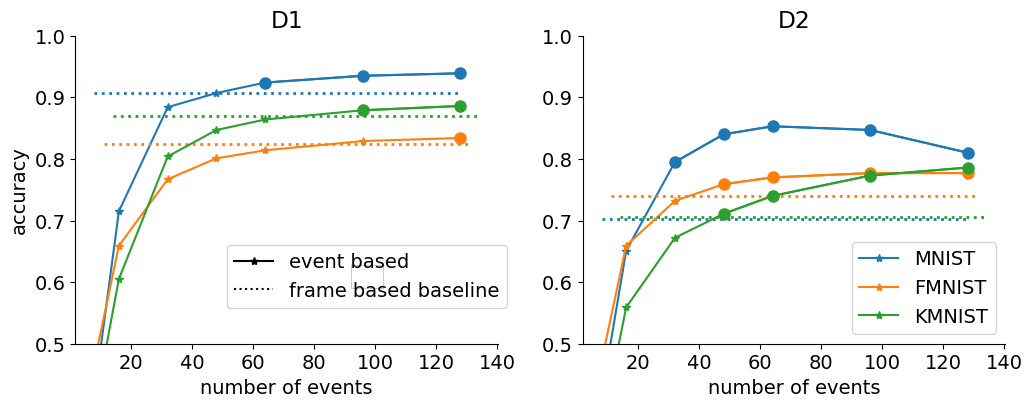

In [19]:
plt.figure(figsize=(12,4))
plt.rcParams.update({'font.size': 14})

styles = [':','--','.-']
# these_ds = dfsum['Dataset'].unique()
these_ds = ['MNIST','FMNIST','KMNIST']
for aaa, this_ds in enumerate(these_ds):
    sub_df = dfsum.loc[dfsum['Dataset']==this_ds]
    ddd = sorted(sub_df['Distance'].unique())
    for dd,this_dist in enumerate(ddd):
        plt.subplot(1,2,dd+1)
        uu = sub_df.loc[sub_df['Distance']==this_dist]
        uu_significant = uu[uu['EB-Greater']==True]
        
        color = plt.gca()._get_lines.get_next_color()  # Get the next color from the color cycle

        plt.plot(uu['n_events'].astype(float).to_numpy(),uu['AccMean'].astype(float).to_numpy(),'-*',
                 color=color,label=this_ds)
        plt.plot(uu_significant['n_events'].astype(float).to_numpy(),uu_significant['AccMean'].astype(float).to_numpy(),marker='o',
                 markersize='8', color=color)
            
        fb_baseline = frames_LUT[(this_ds,this_dist)]
        plt.plot(aaa*3+uu['n_events'].astype(float).to_numpy(),fb_baseline+0*uu['AccMean'].astype(float).to_numpy(),
                 ':', linewidth=2,
                 color=color)

        plt.xlabel('number of events')
        plt.ylim(0.5,1.0)
        plt.title(this_dist)
        ax = plt.gca()
        
        ##
        panel = 'panelA' if this_dist=='D1' else 'panelB'
        uu[['n_events', 'AccMean','AccStd']].to_csv(f'fig2{panel}_{this_ds}_{this_dist}.csv', index=False)
        print(f'FB baseline: {this_ds}, {this_dist}: {fb_baseline}')
        ##

        ax.spines[['right', 'top']].set_visible(False)
plt.legend()
ax = plt.gca()
# ax.spines[['left','right', 'top']].set_visible(False)

# plt.yticks([0.5,1])
plt.subplot(1,2,1)
plt.ylabel('accuracy')
ax = plt.gca()

add_inset_with_symbols(ax, width="15%", height="15%", loc=4, styles=['k-*','k:'], 
                       titles = ['event based', 'frame based baseline'] ,
                       bbox=(0.25,0.15,0.5,0.5))

# plt.savefig('fig2ab.png', bbox_inches='tight')

# import matplotlib as mpl
# mpl.rcParams['svg.fonttype'] = 'none' #for editable text
# plt.savefig('fig2ab.svg', bbox_inches='tight')


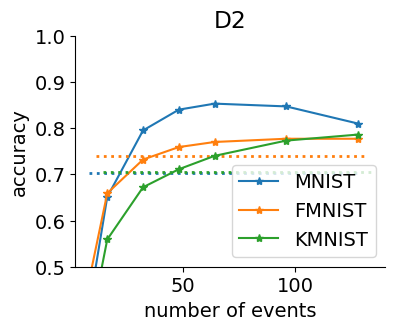

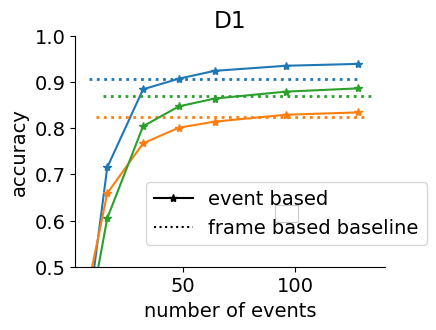

In [18]:
plt.figure(1,figsize=(4,3))
plt.rcParams.update({'font.size': 14})

plt.figure(2,figsize=(4,3))
plt.rcParams.update({'font.size': 14})

styles = [':','--','.-']
# these_ds = dfsum['Dataset'].unique()
these_ds = ['MNIST','FMNIST','KMNIST']
for aaa, this_ds in enumerate(these_ds):
    sub_df = dfsum.loc[dfsum['Dataset']==this_ds]
    ddd = sorted(sub_df['Distance'].unique())
    for dd,this_dist in enumerate(ddd):
        plt.figure(dd+1)
        uu = sub_df.loc[sub_df['Distance']==this_dist]
        
        color = plt.gca()._get_lines.get_next_color()  # Get the next color from the color cycle

        plt.plot(uu['n_events'].astype(float).to_numpy(),uu['AccMean'].astype(float).to_numpy(),'-*',
                 color=color,label=this_ds)
        fb_baseline = frames_LUT[(this_ds,this_dist)]
        plt.plot(aaa*3+uu['n_events'].astype(float).to_numpy(),fb_baseline+0*uu['AccMean'].astype(float).to_numpy(),
                 ':', linewidth=2,
                 color=color)

        plt.xlabel('number of events')
        plt.ylabel('accuracy')       
        plt.ylim(0.5,1.0)
        plt.title(this_dist)
        ax = plt.gca()

        ax.spines[['right', 'top']].set_visible(False)

plt.figure(2)

plt.legend(loc=4)
ax = plt.gca()
# ax.spines[['left','right', 'top']].set_visible(False)

# plt.yticks([0.5,1])
# plt.subplot(1,2,1)
plt.ylabel('accuracy')

plt.figure(1)
ax = plt.gca()

add_inset_with_symbols(ax, width="15%", height="15%", loc=4, styles=['k-*','k:'], 
                       titles = ['event based', 'frame based baseline'] ,
                       bbox=(0.25,0.15,0.5,0.5))

In [19]:
dfsum[dfsum['n_events']==96]

,Dataset,Distance,n_events,AccMean,AccStd,AccCnt,AccSem,Date
3,MNIST,D1,96,0.935,0.002,5.000,0.001,20250724
10,FMNIST,D1,96,0.829,0.004,5.000,0.002,20250803
38,KMNIST,D2,96,0.773,0.003,5.000,0.001,20250909
17,KMNIST,D1,96,0.879,0.001,5.000,0.001,20250730_2
24,MNIST,D2,96,0.847,0.005,5.000,0.002,20250809
31,FMNIST,D2,96,0.777,0.001,5.000,0.000,20250810_2


In [20]:
dfsum.loc[:,dfsum.columns != 'Date']

,Dataset,Distance,n_events,AccMean,AccStd,AccCnt,AccSem
6,MNIST,D1,8,0.418,0.003,5.000,0.001
13,FMNIST,D1,8,0.471,0.005,5.000,0.003
27,MNIST,D2,8,0.416,0.002,5.000,0.001
20,KMNIST,D1,8,0.393,0.001,5.000,0.000
41,KMNIST,D2,8,0.362,0.003,5.000,0.001
34,FMNIST,D2,8,0.473,0.002,5.000,0.001
15,KMNIST,D1,16,0.605,0.002,5.000,0.001
29,FMNIST,D2,16,0.659,0.002,5.000,0.001
22,MNIST,D2,16,0.651,0.002,5.000,0.001
36,KMNIST,D2,16,0.559,0.003,5.000,0.001


In [21]:
dfsum[['Dataset', 'Distance', 'n_events', 'AccCnt','AccMean','AccStd','AccSem' ]]

,Dataset,Distance,n_events,AccCnt,AccMean,AccStd,AccSem
6,MNIST,D1,8,5.000,0.418,0.003,0.001
13,FMNIST,D1,8,5.000,0.471,0.005,0.003
27,MNIST,D2,8,5.000,0.416,0.002,0.001
20,KMNIST,D1,8,5.000,0.393,0.001,0.000
41,KMNIST,D2,8,5.000,0.362,0.003,0.001
34,FMNIST,D2,8,5.000,0.473,0.002,0.001
15,KMNIST,D1,16,5.000,0.605,0.002,0.001
29,FMNIST,D2,16,5.000,0.659,0.002,0.001
22,MNIST,D2,16,5.000,0.651,0.002,0.001
36,KMNIST,D2,16,5.000,0.559,0.003,0.001


In [22]:
import pandas as pd

def df_to_latex_table(df: pd.DataFrame, new_column_names: dict = None, column_formats: dict = None, default_format: str = ".3f") -> str:
    """
    Convert a pandas DataFrame to a LaTeX table string with optional column renaming, formatting, and multi-line headers.
    
    Parameters:
        df (pd.DataFrame): The DataFrame to convert.
        new_column_names (dict, optional): A dictionary to rename columns. 
                                           Format: {'old_name': 'new_name'}.
        column_formats (dict, optional): A dictionary specifying format for columns.
                                         Format: {'column_name': 'format_specifier'}.
                                         Example: {'A': '.2f', 'B': 'd'}.
        default_format (str, optional): Default formatting for numeric values. Defaults to '.3f'.
                                           
    Returns:
        str: Full LaTeX code for the table.
    """
    def try_convert_to_number(value):
        """Try to convert a value to a number if it looks like one."""
        try:
            return float(value) if '.' in str(value) else int(value)
        except ValueError:
            return value

    def format_header(header):
        """Format a column header to split long text into multiple lines using \makecell."""
        return "\\makecell{" + " \\\\ ".join(header.split()) + "}"

    # Rename columns if new_column_names is provided
    if new_column_names:
        df = df.rename(columns=new_column_names)
    
    # Apply formatting to columns if column_formats is provided
    formatted_df = df.copy()
    for col in formatted_df.columns:
        if column_formats and col in column_formats:
            fmt = column_formats[col]
        else:
            fmt = default_format  # Use default format for unspecified columns
        
        formatted_df[col] = formatted_df[col].apply(
            lambda x: f"{try_convert_to_number(x):{fmt}}" 
                      if pd.notnull(x) and isinstance(try_convert_to_number(x), (int, float)) 
                      else x
        )
    
    # Start the LaTeX table
    latex_code = "\\begin{table}[ht]\n\\centering\n"
    latex_code += "\\begin{tabular}{" + " | ".join(["c"] * len(formatted_df.columns)) + "}\n"
    latex_code += "\\hline\n"
    
    # Add column headers with multi-line formatting
    formatted_headers = [format_header(header) for header in formatted_df.columns]
    latex_code += " & ".join(formatted_headers) + " \\\\\n"
    latex_code += "\\hline\n"
    
    # Add rows
    for _, row in formatted_df.iterrows():
        latex_code += " & ".join(map(str, row)) + " \\\\\n"
        latex_code += "\\hline\n"
    
    # End the LaTeX table
    latex_code += "\\end{tabular}\n"
    latex_code += "\\caption{Your table caption here.}\n"
    latex_code += "\\label{tab:your_label_here}\n"
    latex_code += "\\end{table}"
    
    return latex_code


<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2334359/3064768270.py:27: SyntaxWarning: invalid escape sequence '\m'
  """Format a column header to split long text into multiple lines using \makecell."""


In [23]:
print(
    df_to_latex_table(dfsum[['Dataset', 'Distance', 'n_events', 'AccCnt','AccMean','AccStd','AccSem' ]],
                     column_formats={'AccCnt':'.0f'})
)

\begin{table}[ht]
\centering
\begin{tabular}{c | c | c | c | c | c | c}
\hline
\makecell{Dataset} & \makecell{Distance} & \makecell{n_events} & \makecell{AccCnt} & \makecell{AccMean} & \makecell{AccStd} & \makecell{AccSem} \\
\hline
MNIST & D1 & 8.000 & 5 & 0.418 & 0.003 & 0.001 \\
\hline
FMNIST & D1 & 8.000 & 5 & 0.471 & 0.005 & 0.003 \\
\hline
MNIST & D2 & 8.000 & 5 & 0.416 & 0.002 & 0.001 \\
\hline
KMNIST & D1 & 8.000 & 5 & 0.393 & 0.001 & 0.000 \\
\hline
KMNIST & D2 & 8.000 & 5 & 0.362 & 0.003 & 0.001 \\
\hline
FMNIST & D2 & 8.000 & 5 & 0.473 & 0.002 & 0.001 \\
\hline
KMNIST & D1 & 16.000 & 5 & 0.605 & 0.002 & 0.001 \\
\hline
FMNIST & D2 & 16.000 & 5 & 0.659 & 0.002 & 0.001 \\
\hline
MNIST & D2 & 16.000 & 5 & 0.651 & 0.002 & 0.001 \\
\hline
KMNIST & D2 & 16.000 & 5 & 0.559 & 0.003 & 0.001 \\
\hline
FMNIST & D1 & 16.000 & 5 & 0.659 & 0.001 & 0.000 \\
\hline
MNIST & D1 & 16.000 & 5 & 0.715 & 0.002 & 0.001 \\
\hline
MNIST & D1 & 32.000 & 5 & 0.884 & 0.003 & 0.002 \\
\hline
FMNIST & D1

### Calculating p-vlaues for EB vs. FB using single-tailed wilcoxon rank-sum test

In [24]:
# ds_LUT = {'20250724':{'ds':'MNIST', 'dist':'D1'},
#           '20250803':{'ds':'FMNIST', 'dist':'D1'},
#           '20250730_2':{'ds':'KMNIST', 'dist':'D1'},
#           '20250809':{'ds':'MNIST', 'dist':'D2'},
#           '20250810_2':{'ds':'FMNIST', 'dist':'D2'},
#           '20250909':{'ds':'KMNIST', 'dist':'D2'}
#          }

# FMNIST D1
# dsid = '20250803'
# sample2 = [0.8245, 0.826,  0.8241, 0.8256, 0.8202]#fb fmnist D1- 20250728
# n_events = 96

# KMNIST D1
dsid = '20250730_2'
sample2 = [0.8668, 0.8703, 0.8705, 0.8714, 0.8707]#fb kmnist D1- 20250729
n_events = 96

# # MNIST D1
# dsid = '20250724'
# sample2 = [0.9078, 0.9057, 0.9077, 0.9061, 0.9085]#fb mnist D1- 20250722
# n_events = 96

# # MNIST D2
# dsid = '20250809'
# sample2 = [0.7027, 0.7048, 0.7026, 0.6974, 0.705 ]#fb mnist D2
# n_events = 48

# # FMNIST D2
# dsid = '20250810_2'
# sample2 = [0.7398, 0.7383, 0.7371, 0.7393, 0.7399]#fb fmnist D2
# n_events = 48

# # KMNIST D2
# dsid = '20250909'
# sample2 = [0.7071, 0.7071, 0.703,  0.7072, 0.7039]#fb kmnist D2
# n_events = 48

ds_ids = df['eb_ds_path'].apply(lambda x: x.split('/')[-1])

sample1 = df[np.logical_and(df['ds_args_n_samples']==n_events, ds_ids==dsid)]['test_acc'].to_numpy()
print(sample1)
print(sample2)

[0.8774 0.8772 0.8779 0.8804 0.8801]
[0.8668, 0.8703, 0.8705, 0.8714, 0.8707]


In [25]:
from scipy.stats import ranksums

# Null hypothesis: samples are drawn from the same distribution
statistic, pvalue = ranksums(sample1, sample2, alternative='two-sided')#alternative='greater')


print(f"Rank-Sum Statistic: {statistic}, p-value: {pvalue}")
# 

Rank-Sum Statistic: 2.6111648393354674, p-value: 0.009023438818080326
